# Bài tập 02: Dự đoán Bệnh Tiểu đường (Diabetes Prediction)

## Phần I: Định nghĩa Tập dữ liệu và Bài toán
- **Tên tập dữ liệu Kaggle**: Diabetes Prediction Dataset
- **URL**: Kaggle Dataset Link
- **Số lượng quan sát & thuộc tính**: Khám phá qua mã nguồn bên dưới.
- **Biến mục tiêu**: `diabetes` (0: Không mắc bệnh, 1: Mắc bệnh tiểu đường).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df_diabetes = pd.read_csv('diabetes_prediction_dataset.csv')
print("Kích thước dataframe ban đầu:", df_diabetes.shape)
display(df_diabetes.head())
df_diabetes.info()


Kích thước dataframe ban đầu: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


## Phần II: Kiểm tra và Hiểu Dữ liệu
Kiểm tra giá trị thiếu, trùng lặp và thống kê mô tả.

In [2]:
print("Thống kê mô tả:")
display(df_diabetes.describe())

print("\nGiá trị thiếu (NaN):")
print(df_diabetes.isna().sum())

print("\nSố bản ghi trùng lặp:", df_diabetes.duplicated().sum())


Thống kê mô tả:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000



Giá trị thiếu (NaN):
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Số bản ghi trùng lặp: 3854


## Phần III: Làm sạch Dữ liệu
Loại bỏ các bản ghi trùng lặp và xử lý các giá trị không hợp lệ.

In [3]:
# Xử lý trùng lặp
initial_count = len(df_diabetes)
df_diabetes = df_diabetes.drop_duplicates()
print(f"Đã loại bỏ {initial_count - len(df_diabetes)} bản ghi trùng lặp.")


Đã loại bỏ 3854 bản ghi trùng lặp.


## Phần IV: Biểu diễn Dữ liệu
Chuyển đổi dữ liệu thô dạng bảng thành ma trận đặc trưng $X \in \mathbb{R}^{N \times d}$ và véc-tơ mục tiêu $y \in \mathbb{R}^N$.

Kích thước ma trận đặc trưng X: (96146, 8)
Kích thước véc-tơ mục tiêu y: (96146,)
Ví dụ véc-tơ đặc trưng một bệnh nhân (mẫu đầu tiên):
{'gender': 'Female', 'age': 80.0, 'hypertension': 0, 'heart_disease': 1, 'smoking_history': 'never', 'bmi': 25.19, 'HbA1c_level': 6.6, 'blood_glucose_level': 140}


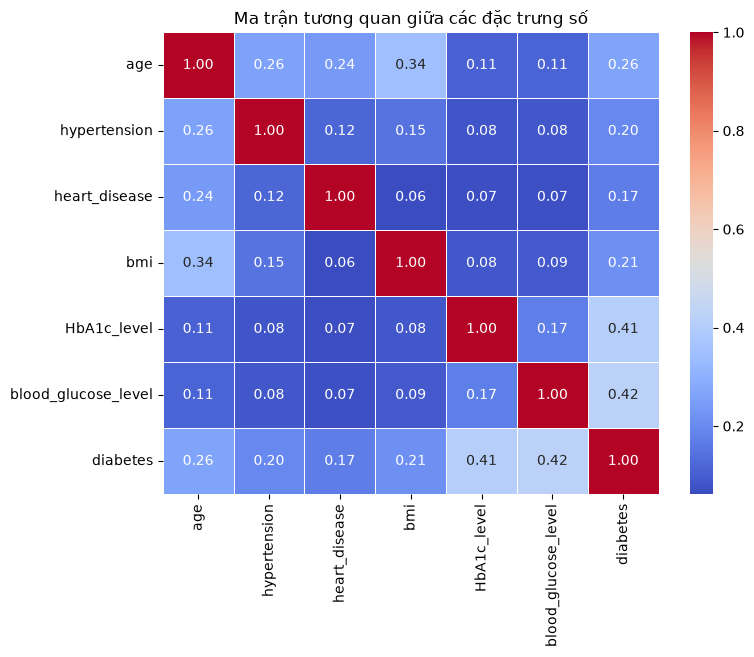

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_diab = df_diabetes.drop(columns=['diabetes'])
y_diab = df_diabetes['diabetes']

print(f"Kích thước ma trận đặc trưng X: {X_diab.shape}")
print(f"Kích thước véc-tơ mục tiêu y: {y_diab.shape}")
print("Ví dụ véc-tơ đặc trưng một bệnh nhân (mẫu đầu tiên):")
print(X_diab.iloc[0].to_dict())

# Biểu đồ ma trận tương quan giữa các biến số trong tập dữ liệu
plt.figure(figsize=(8, 6))
numeric_cols = df_diabetes.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_diabetes[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng số')
plt.show()


## Phần V: Phân tích Khám phá Dữ liệu (EDA)
Trực quan hóa phân phối mục tiêu và các đặc trưng quan trọng kèm phân tích.

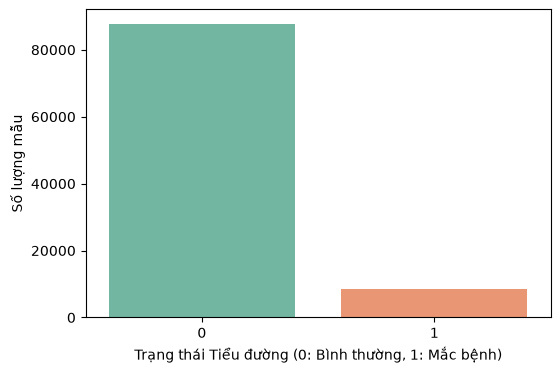

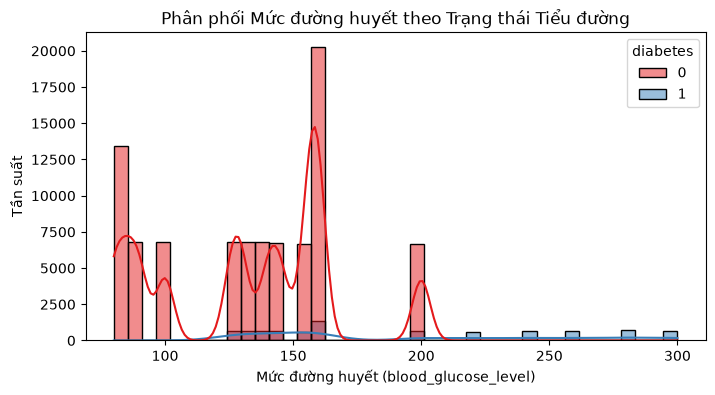

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diabetes', data=df_diabetes, hue='diabetes', palette='Set2', legend=False)
plt.xlabel('Trạng thái Tiểu đường (0: Bình thường, 1: Mắc bệnh)')
plt.ylabel('Số lượng mẫu')
plt.show()

# Quan sát: Dữ liệu bị mất cân bằng rõ rệt với số lượng người không mắc bệnh chiếm đa số.
# Diễn giải: Cần chú ý khi đánh giá mô hình, độ chính xác (accuracy) đơn thuần có thể gây hiểu lầm.
# Ý nghĩa học máy: Phải sử dụng các chỉ số Precision, Recall, F1-score và xem xét kỹ thuật xử lý mất cân bằng lớp.

# Biểu đồ phân phối mức đường huyết theo trạng thái tiểu đường
plt.figure(figsize=(8, 4))
sns.histplot(data=df_diabetes, x='blood_glucose_level', hue='diabetes', kde=True, palette='Set1', bins=40)
plt.title('Phân phối Mức đường huyết theo Trạng thái Tiểu đường')
plt.xlabel('Mức đường huyết (blood_glucose_level)')
plt.ylabel('Tần suất')
plt.show()


## Phần VI: Dữ liệu Huấn luyện, Kiểm định và Kiểm tra
Phân chia tập dữ liệu theo tỷ lệ 80% huấn luyện, 20% kiểm tra có phân tầng (stratified).

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42, stratify=y_diab
)
print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)


Kích thước tập huấn luyện: (76916, 8)
Kích thước tập kiểm tra: (19230, 8)


## Phần VII & VIII: Phát triển và Đánh giá 5 Mô hình
Huấn luyện và so sánh 5 mô hình: Logistic Regression, Decision Tree, Random Forest, SVM, KNN.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Tiền xử lý cho cột số và phân loại
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_features = ['gender', 'smoking_history']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=50, class_weight='balanced'),
    "SVM": SVC(class_weight='balanced'),
    "KNN": KNeighborsClassifier()
}
results = []
trained_pipelines = {}

for name, clf in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})
    trained_pipelines[name] = pipeline

df_res = pd.DataFrame(results)
display(df_res)


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.884399,0.424950,0.879717,0.573075
1,Decision Tree,0.951950,0.718573,0.748231,0.733102
2,Random Forest,0.956578,0.754885,0.751769,0.753323
3,SVM,0.881331,0.420768,0.917453,0.576937
4,KNN,0.959750,0.891341,0.619104,0.730689


## Phần IX: So sánh Mô hình & Biện minh lựa chọn
Lựa chọn Random Forest làm mô hình tối ưu dựa trên điểm F1-score và độ ổn định.

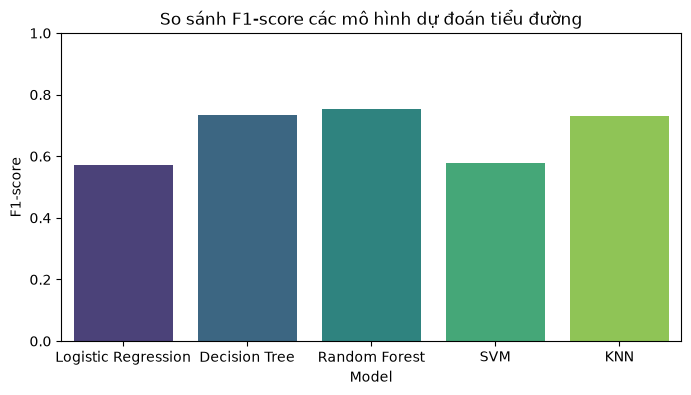

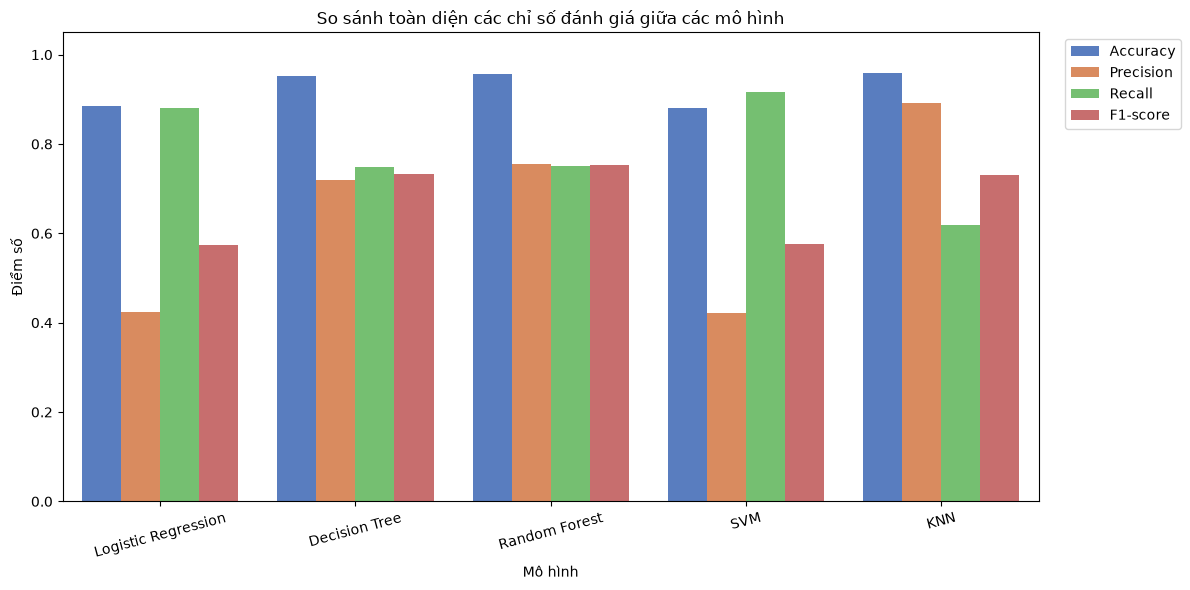

In [8]:
# Biểu đồ so sánh F1-score giữa các mô hình
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='F1-score', data=df_res, hue='Model', palette='viridis', legend=False)
plt.title('So sánh F1-score các mô hình dự đoán tiểu đường')
plt.ylim(0, 1.0)
plt.show()

# Chuyển đổi dữ liệu kết quả về dạng dài (long-form) để vẽ biểu đồ nhóm (grouped barplot)
df_res_melted = df_res.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'], 
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_res_melted, palette='muted')
plt.title('So sánh toàn diện các chỉ số đánh giá giữa các mô hình')
plt.ylim(0, 1.05)
plt.xlabel('Mô hình')
plt.ylabel('Điểm số')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Phần X: Lưu trữ Mô hình (Persistence)
Lưu pipeline hoàn chỉnh bằng joblib.

In [9]:
import joblib

best_pipeline = trained_pipelines["Random Forest"]
joblib.dump(best_pipeline, "diabetes_model_pipeline.joblib")
print("Đã lưu pipeline mô hình tiểu đường thành công vào 'diabetes_model_pipeline.joblib'")


Đã lưu pipeline mô hình tiểu đường thành công vào 'diabetes_model_pipeline.joblib'
